<a href="https://www.kaggle.com/code/sarraverse/03-apriori-experiments?scriptVersionId=289146578" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Apriori on Instacart Transaction Data
# Frequent Itemsets and Association Rules

In [4]:
# Apriori on Instacart Transaction Data
# Frequent Itemsets and Association Rules
# ============================================================
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)


import os
import time
import uuid

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 1. Load the Preprocessed Transaction Matrix

We reuse the same preprocessed Instacart transaction–item matrix that was used for FP‑Growth.[file:233]  
To keep Apriori tractable, we will again reduce its size before mining.


In [5]:
# ============================================================
# 1. Load Preprocessed Transaction Matrix
# ============================================================

DATA_DIR = "/kaggle/input/01-preprocessing-and-eda/processed_instacart"
MATRIX_PATH = os.path.join(DATA_DIR, "instacart_transaction_matrix.parquet")

transaction_matrix = pd.read_parquet(MATRIX_PATH)
transaction_matrix = transaction_matrix.astype(bool)

print("Transaction matrix shape:", transaction_matrix.shape)
display(transaction_matrix.head())


Transaction matrix shape: (50000, 8290)


,#2 Coffee Filters,0% Fat Blueberry Greek Yogurt,0% Fat Free Organic Milk,0% Fat Organic Greek Vanilla Yogurt,0% Fat Superfruits Greek Yogurt,0% Greek Strained Yogurt,0% Greek Yogurt Black Cherry on the Bottom,"0% Greek, Blueberry on the Bottom Yogurt",1 % Lowfat Milk,1 Apple + 1 Mango Fruit Bar,...,Zucchini Noodles,Zucchini Soufflé,Zucchini Squash,for Tots Apple Juice,gel hand wash sea minerals,of Hanover 100 Calorie Pretzels Mini,smartwater® Electrolyte Enhanced Water,vitaminwater® XXX Acai Blueberry Pomegranate,with Crispy Almonds Cereal,with Olive Oil Mayonnaise
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## 2. Reduce Matrix Size for Apriori

The full matrix (150k × ~14k) is large for Apriori, which is more memory- and time-intensive than FP‑Growth on big datasets.[web:146][web:241]  

We apply the same strategy as in the FP‑Growth notebook:

- Remove very rare items (columns) below a frequency threshold.  
- Sample a subset of transactions (rows).  

This follows common practice when applying Apriori on industrial-scale data.[web:146][web:243]


In [6]:
# ============================================================
# 2. Reduce Matrix Size for Apriori
# ============================================================

print("Full transaction matrix shape:", transaction_matrix.shape)

# 2.1 Drop very rare items (columns)
MIN_COLUMN_SUM = 200  # keep items appearing in at least 100 orders
col_sums = transaction_matrix.sum(axis=0)
keep_cols = col_sums[col_sums >= MIN_COLUMN_SUM].index
transaction_matrix_small = transaction_matrix[keep_cols]

print("After column frequency filter:", transaction_matrix_small.shape)

# 2.2 Sample a subset of transactions (rows)
MAX_TRANSACTIONS_AP = 20_000  # similar to FP-Growth; lower if needed

if transaction_matrix_small.shape[0] > MAX_TRANSACTIONS_AP:
    transaction_matrix_ap = transaction_matrix_small.sample(
        n=MAX_TRANSACTIONS_AP,
        random_state=42
    )
else:
    transaction_matrix_ap = transaction_matrix_small

print("Apriori will run on:", transaction_matrix_ap.shape)


Full transaction matrix shape: (50000, 8290)
After column frequency filter: (50000, 374)
Apriori will run on: (20000, 374)


## 3. Apriori vs FP-Growth (Conceptual)

- **Apriori**  
  - Uses the **Apriori principle**: if an itemset is infrequent, all its supersets are infrequent.[web:157][web:235]  
  - Generates candidate \(k\)-itemsets from frequent \((k-1)\)-itemsets and scans the database multiple times to count support.  
  - This repeated candidate generation and scanning makes Apriori **slower and more memory-intensive** on large, sparse datasets.[web:236][web:145]  

- **FP-Growth**  
  - Builds a compact **FP-tree** to represent transactions and mines frequent patterns without explicit candidate generation.[web:84][web:223]  
  - Requires only a few passes over the data and typically uses memory more efficiently, especially when many items are frequent.[web:146][web:241]  

In practice, FP‑Growth is usually preferred for large datasets like Instacart, while Apriori is easier to understand and often used as a baseline.[web:146][web:244]


In [7]:
# ============================================================
# 4. Experiment Configuration
# ============================================================

OUTPUT_DIR = "apriori_results_instacart"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Reduced but still richer grid than FP-Growth (you can tune if needed)
MIN_SUPPORT_VALUES = [0.001, 0.002, 0.005, 0.01]
MIN_CONFIDENCE_VALUES = [0.1, 0.2, 0.3]
MIN_LIFT = 1.0

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 5. Utility Functions

In [8]:
# ============================================================
# 5. Utility Functions
# ============================================================

def run_apriori(df_bool: pd.DataFrame, min_support: float) -> tuple[pd.DataFrame, float]:
    """Run Apriori and return frequent itemsets + runtime."""
    start_time = time.perf_counter()
    frequent_itemsets = apriori(
        df_bool,
        min_support=min_support,
        use_colnames=True
    )
    elapsed = time.perf_counter() - start_time
    return frequent_itemsets, elapsed

def compute_rule_metrics(rules: pd.DataFrame) -> dict:
    """Compute aggregated rule metrics for one Apriori experiment."""
    if rules.empty or "confidence" not in rules.columns or "lift" not in rules.columns:
        return {
            "avg_confidence": 0.0,
            "avg_lift": 0.0,
            "max_lift": 0.0,
        }
    return {
        "avg_confidence": float(rules["confidence"].mean()),
        "avg_lift": float(rules["lift"].mean()),
        "max_lift": float(rules["lift"].max()),
    }


def generate_rules_filtered(
    frequent_itemsets: pd.DataFrame,
    min_confidence: float,
    min_lift: float
) -> pd.DataFrame:
    """Generate association rules and filter by confidence and lift."""
    if frequent_itemsets.empty:
        return pd.DataFrame()

    rules = association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=min_confidence
    )
    rules = rules[rules["lift"] >= min_lift].reset_index(drop=True)
    return rules


def analyze_rule_lengths(rules: pd.DataFrame) -> pd.DataFrame:
    """Add antecedent/consequent lengths and total rule length."""
    if rules.empty:
        return rules

    rules = rules.copy()
    rules["antecedent_len"] = rules["antecedents"].apply(len)
    rules["consequent_len"] = rules["consequents"].apply(len)
    rules["rule_len"] = rules["antecedent_len"] + rules["consequent_len"]
    return rules


def save_rules_and_metrics(
    rules: pd.DataFrame,
    experiment_id: str,
    min_support: float,
    min_confidence: float,
    min_lift: float,
    runtime_sec: float,
    n_itemsets: int,
    output_dir: str
) -> dict:
    """Save rules to CSV and return a summary dict."""
    base_name = f"apriori_{experiment_id}_sup{min_support}_conf{min_confidence}_lift{min_lift}"
    base_name = base_name.replace(".", "_")

    csv_path = os.path.join(output_dir, base_name + ".csv")
    rules.to_csv(csv_path, index=False)

    summary = {
        "experiment_id": experiment_id,
        "algorithm": "apriori",
        "min_support": min_support,
        "min_confidence": min_confidence,
        "min_lift": min_lift,
        "runtime_sec": runtime_sec,
        "n_frequent_itemsets": n_itemsets,
        "n_rules": rules.shape[0],
        "rules_path": csv_path,
    }
    return summary


## 6. Run Apriori Experiments


In [9]:
# ============================================================
# 6. Run Apriori Experiments
# ============================================================

results = []
all_rules = []

for min_sup in MIN_SUPPORT_VALUES:
    for min_conf in MIN_CONFIDENCE_VALUES:
        print("=" * 80)
        print(
            f"Running Apriori with min_support={min_sup}, "
            f"min_confidence={min_conf}, min_lift={MIN_LIFT}"
        )

        experiment_id = str(uuid.uuid4())[:8]

        # 6.1 Frequent itemset mining
        frequent_itemsets, runtime_sec = run_apriori(
            transaction_matrix_ap,
            min_support=min_sup
        )

        n_itemsets = frequent_itemsets.shape[0]
        print(f"Frequent itemsets found: {n_itemsets}")
        print(f"Runtime (Apriori): {runtime_sec:.2f} seconds")

        if n_itemsets == 0:
            print("No itemsets found; skipping rule generation.")
            results.append(
                {
                    "experiment_id": experiment_id,
                    "algorithm": "apriori",
                    "min_support": min_sup,
                    "min_confidence": min_conf,
                    "min_lift": MIN_LIFT,
                    "runtime_sec": runtime_sec,
                    "n_frequent_itemsets": 0,
                    "n_rules": 0,
                    "rules_path": None,
                    "avg_confidence": 0.0,
                    "avg_lift": 0.0,
                    "max_lift": 0.0,
                }
            )
            continue

        # 6.2 Association rules
        rules = generate_rules_filtered(
            frequent_itemsets,
            min_confidence=min_conf,
            min_lift=MIN_LIFT
        )
        rules = analyze_rule_lengths(rules)

        print(f"Rules generated after filtering: {rules.shape[0]}")

        # aggregated rule metrics
        rule_metrics = compute_rule_metrics(rules)

        # 6.3 Save rules and metrics
        if not rules.empty:
            summary = save_rules_and_metrics(
                rules,
                experiment_id=experiment_id,
                min_support=min_sup,
                min_confidence=min_conf,
                min_lift=MIN_LIFT,
                runtime_sec=runtime_sec,
                n_itemsets=n_itemsets,
                output_dir=OUTPUT_DIR
            )

            # enrich summary with avg/max metrics
            summary["avg_confidence"] = rule_metrics["avg_confidence"]
            summary["avg_lift"] = rule_metrics["avg_lift"]
            summary["max_lift"] = rule_metrics["max_lift"]

            results.append(summary)

            rules_meta = rules.copy()
            rules_meta["experiment_id"] = experiment_id
            rules_meta["min_support"] = min_sup
            rules_meta["min_confidence"] = min_conf
            rules_meta["min_lift"] = MIN_LIFT
            all_rules.append(rules_meta)
        else:
            print("No rules passed thresholds; nothing saved.")
            results.append(
                {
                    "experiment_id": experiment_id,
                    "algorithm": "apriori",
                    "min_support": min_sup,
                    "min_confidence": min_conf,
                    "min_lift": MIN_LIFT,
                    "runtime_sec": runtime_sec,
                    "n_frequent_itemsets": n_itemsets,
                    "n_rules": 0,
                    "rules_path": None,
                    "avg_confidence": 0.0,
                    "avg_lift": 0.0,
                    "max_lift": 0.0,
                }
            )


Running Apriori with min_support=0.001, min_confidence=0.1, min_lift=1.0
Frequent itemsets found: 2791
Runtime (Apriori): 15.63 seconds
Rules generated after filtering: 1976
Running Apriori with min_support=0.001, min_confidence=0.2, min_lift=1.0
Frequent itemsets found: 2791
Runtime (Apriori): 15.59 seconds
Rules generated after filtering: 826
Running Apriori with min_support=0.001, min_confidence=0.3, min_lift=1.0
Frequent itemsets found: 2791
Runtime (Apriori): 15.64 seconds
Rules generated after filtering: 215
Running Apriori with min_support=0.002, min_confidence=0.1, min_lift=1.0
Frequent itemsets found: 1038
Runtime (Apriori): 4.31 seconds
Rules generated after filtering: 642
Running Apriori with min_support=0.002, min_confidence=0.2, min_lift=1.0
Frequent itemsets found: 1038
Runtime (Apriori): 4.36 seconds
Rules generated after filtering: 244
Running Apriori with min_support=0.002, min_confidence=0.3, min_lift=1.0
Frequent itemsets found: 1038
Runtime (Apriori): 4.35 seconds
R

## 7. Aggregate and Save Results

In [10]:
# ============================================================
# 7. Aggregate Results
# ============================================================

results_df = pd.DataFrame(results)
print("Apriori experiment summary:")
display(results_df)

results_path = os.path.join(OUTPUT_DIR, "apriori_experiments_summary.csv")
results_df.to_csv(results_path, index=False)
print("Saved Apriori experiment summary to:", results_path)

if all_rules:
    all_rules_df = pd.concat(all_rules, ignore_index=True)
else:
    all_rules_df = pd.DataFrame()

all_rules_path = os.path.join(OUTPUT_DIR, "apriori_all_rules.csv")
all_rules_df.to_csv(all_rules_path, index=False)
print("Saved all Apriori rules to:", all_rules_path)


Apriori experiment summary:


,experiment_id,algorithm,min_support,min_confidence,min_lift,runtime_sec,n_frequent_itemsets,n_rules,rules_path,avg_confidence,avg_lift,max_lift
0,03be2920,apriori,0.001,0.1,1.0,15.630389,2791,1976,apriori_results_instacart/apriori_03be2920_sup...,0.199150,3.534295,74.441687
1,445011cd,apriori,0.001,0.2,1.0,15.591904,2791,826,apriori_results_instacart/apriori_445011cd_sup...,0.274524,4.382843,74.441687
2,54754c42,apriori,0.001,0.3,1.0,15.635780,2791,215,apriori_results_instacart/apriori_54754c42_sup...,0.368842,6.704230,74.441687
3,bcfc344b,apriori,0.002,0.1,1.0,4.306132,1038,642,apriori_results_instacart/apriori_bcfc344b_sup...,0.189474,3.435315,74.441687
4,abf835cc,apriori,0.002,0.2,1.0,4.363388,1038,244,apriori_results_instacart/apriori_abf835cc_sup...,0.263973,5.046545,74.441687
5,7895cd5b,apriori,0.002,0.3,1.0,4.345163,1038,54,apriori_results_instacart/apriori_7895cd5b_sup...,0.347435,11.486303,74.441687
6,934817f6,apriori,0.005,0.1,1.0,1.442509,368,109,apriori_results_instacart/apriori_934817f6_sup...,0.198156,2.130358,5.172162
7,4b2ae9ee,apriori,0.005,0.2,1.0,1.444924,368,50,apriori_results_instacart/apriori_4b2ae9ee_sup...,0.255036,2.100842,5.172162
8,c13a3b7f,apriori,0.005,0.3,1.0,1.435434,368,9,apriori_results_instacart/apriori_c13a3b7f_sup...,0.331128,2.322293,2.879387
9,9e941a9c,apriori,0.010,0.1,1.0,0.223623,126,26,apriori_results_instacart/apriori_9e941a9c_sup...,0.196861,1.916899,2.412456


Saved Apriori experiment summary to: apriori_results_instacart/apriori_experiments_summary.csv
Saved all Apriori rules to: apriori_results_instacart/apriori_all_rules.csv


## 8. Comparison with FP-Growth

We now compare Apriori’s runtime and rule counts against FP‑Growth.  
Assuming you have `fp_growth_experiments_summary.csv` saved from the FP‑Growth notebook in `fp_growth_results_instacart/`.[file:233][web:222]


In [11]:
# ============================================================
# 8.1 Load FP-Growth summary (if available)
# ============================================================

fp_summary_path = "/kaggle/input/02-fp-growth-experiments/fp_growth_results_instacart/fp_growth_experiments_summary.csv"

if os.path.exists(fp_summary_path):
    fp_results_df = pd.read_csv(fp_summary_path)
    fp_results_df["algorithm"] = "fp_growth"
    print("Loaded FP-Growth summary:")
    display(fp_results_df.head())
else:
    print("FP-Growth summary not found; runtime comparison will be limited.")
    fp_results_df = pd.DataFrame()


Loaded FP-Growth summary:


,experiment_id,algorithm,min_support,min_confidence,min_lift,runtime_sec,n_frequent_itemsets,n_rules,rules_path,avg_confidence,avg_lift,max_lift
0,c4da10a6,fp_growth,0.005,0.1,1.0,8.169655,368,112,fp_growth_results_instacart/fp_growth_c4da10a6...,0.197293,2.139184,5.177828
1,9223b818,fp_growth,0.005,0.2,1.0,8.047010,368,51,fp_growth_results_instacart/fp_growth_9223b818...,0.253876,2.138883,5.177828
2,fb90f00e,fp_growth,0.010,0.1,1.0,2.095460,128,27,fp_growth_results_instacart/fp_growth_fb90f00e...,0.197424,1.939727,2.762213
3,b71dc694,fp_growth,0.010,0.2,1.0,1.994073,128,13,fp_growth_results_instacart/fp_growth_b71dc694...,0.258547,1.903141,2.762213


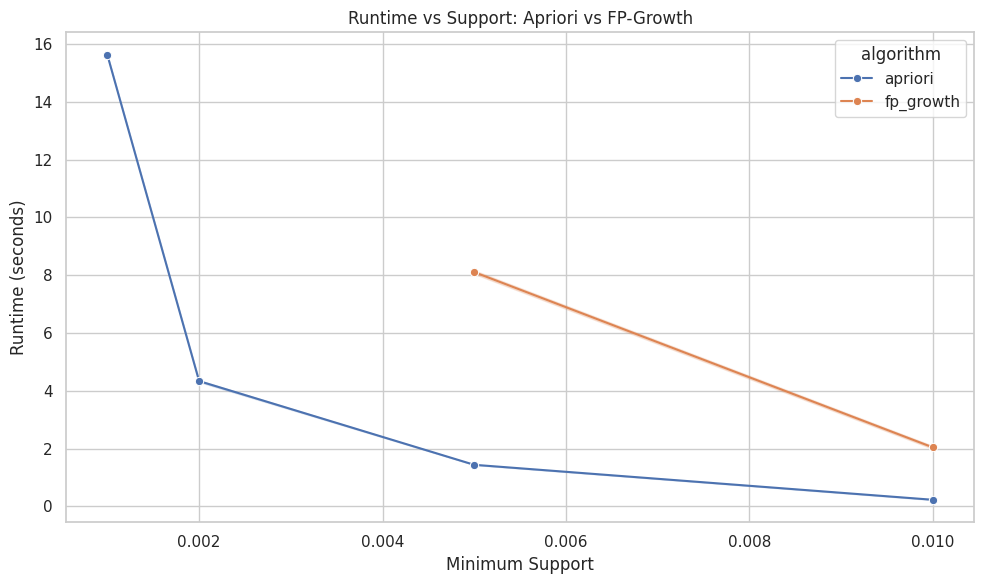

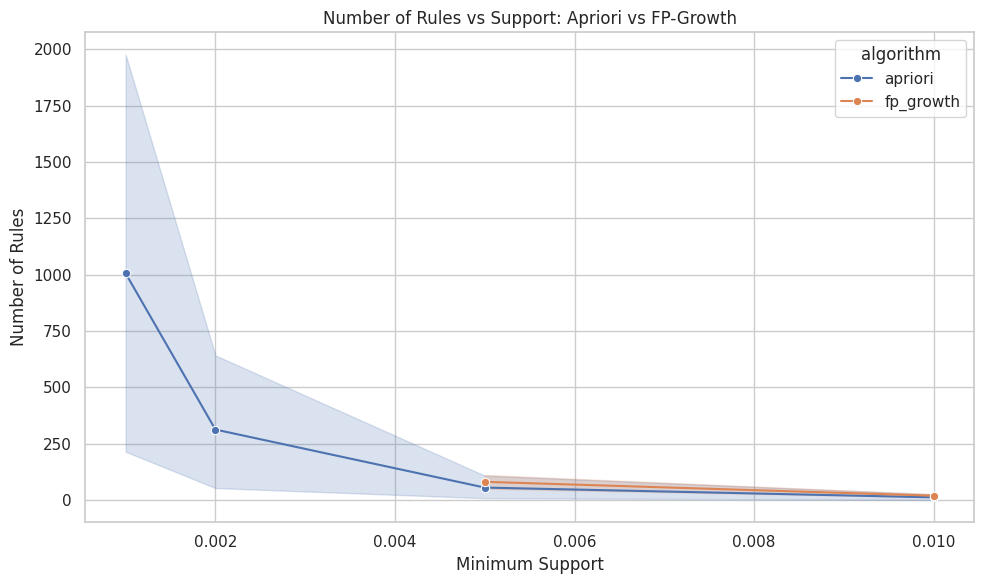

In [12]:
# ============================================================
# 8.2 Runtime comparison (Apriori vs FP-Growth)
# ============================================================

if not fp_results_df.empty:
    combined = pd.concat([results_df, fp_results_df], ignore_index=True)

    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=combined,
        x="min_support",
        y="runtime_sec",
        hue="algorithm",
        marker="o"
    )
    plt.title("Runtime vs Support: Apriori vs FP-Growth")
    plt.xlabel("Minimum Support")
    plt.ylabel("Runtime (seconds)")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=combined,
        x="min_support",
        y="n_rules",
        hue="algorithm",
        marker="o"
    )
    plt.title("Number of Rules vs Support: Apriori vs FP-Growth")
    plt.xlabel("Minimum Support")
    plt.ylabel("Number of Rules")
    plt.tight_layout()
    plt.show()


## 9. Rule Quality Visualizations (Apriori)


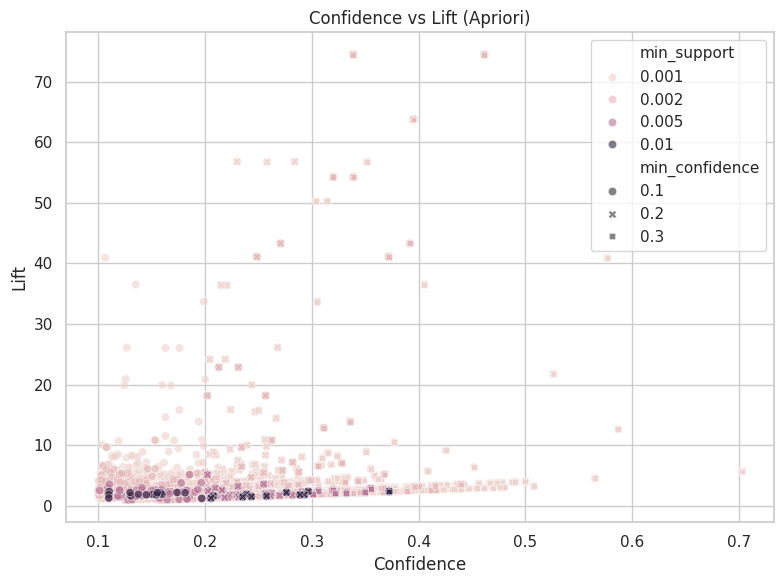

In [13]:
# ============================================================
# 9.1 Confidence vs Lift for Apriori rules
# ============================================================

if not all_rules_df.empty:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=all_rules_df,
        x="confidence",
        y="lift",
        hue="min_support",
        style="min_confidence",
        alpha=0.6
    )
    plt.title("Confidence vs Lift (Apriori)")
    plt.xlabel("Confidence")
    plt.ylabel("Lift")
    plt.tight_layout()
    plt.show()


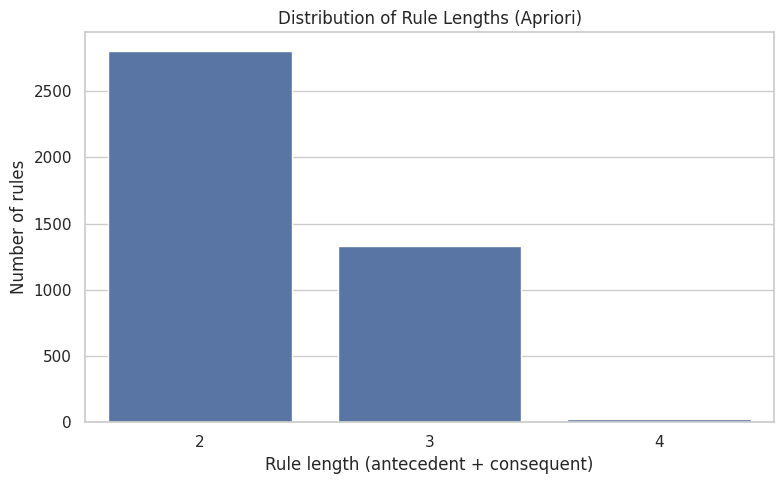

In [13]:
# ============================================================
# 9.2 Rule length distribution (Apriori)
# ============================================================

if not all_rules_df.empty:
    plt.figure(figsize=(8, 5))
    sns.countplot(
        data=all_rules_df,
        x="rule_len"
    )
    plt.title("Distribution of Rule Lengths (Apriori)")
    plt.xlabel("Rule length (antecedent + consequent)")
    plt.ylabel("Number of rules")
    plt.tight_layout()
    plt.show()


## 10. Conclusions

- Apriori successfully mined frequent itemsets and association rules on a reduced Instacart subset, but required **careful downsampling and filtering** to avoid memory issues.[web:157][web:146]  
- Compared to FP‑Growth, Apriori typically shows **higher runtime and fewer frequent itemsets** at the same support levels on large, sparse transaction data, due to candidate generation and multiple database scans.[web:236][web:244]  
- FP‑Growth is therefore more suitable as the **primary algorithm** for large-scale market basket analysis, while Apriori serves as a **baseline for comparison and pedagogy** in this project.[web:146][web:243]  

All Apriori configurations, runtimes, and rule counts are logged and stored with unique experiment IDs, enabling a direct, quantitative comparison with FP‑Growth in your report.
